In [1]:
# MobileNet v2는 주로 대규모 이미지 데이터셋인 ImageNet 데이터베이스를 기반으로 학습된 사전 훈련모델을 사용

import tensorflow as tf

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step


In [2]:
# 정규화
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# 인코딩
NUM_CLASSES = 10
y_train = tf.keras.utils.to_categorical(y_train, NUM_CLASSES) # 원핫인코딩
y_test = tf.keras.utils.to_categorical(y_test, NUM_CLASSES)

print('train data : ', x_train.shape, y_train.shape) # (50000, 32, 32, 3) (50000, 10)
print('test data : ', x_test.shape, y_test.shape) # (10000, 32, 32, 3) (10000, 10)

train data :  (50000, 32, 32, 3) (50000, 10)
test data :  (10000, 32, 32, 3) (10000, 10)


In [3]:
# MobileNet v2 모델 불러오기
Mobilenet_model = tf.keras.applications.MobileNetV2(
    input_shape=(32, 32, 3),
    include_top=True,   # 기본 분류기 포함
    weights=None,       # 모델 구조만 불러오고 모든 가중치는 랜덤 처리
    classes=NUM_CLASSES # cifar10의 클래스 수로 지정
)

print(Mobilenet_model.summary())

Model: "mobilenetv2_1.00_32"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 16, 16,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 16, 16,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 16, 16,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 16, 16,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 16, 16,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 16, 16,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 16, 16,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 16, 16,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 17, 17,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 8, 8, 96)  │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 8, 8, 96)  │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 8, 8, 96)  │          0 │ block_1_depthwis… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 8, 8, 24)  │      2,304 │ block_1_depthwis

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 2,236,682 (8.53 MB)

 Non-trainable params: 34,112 (133.25 KB)

None


In [6]:
Mobilenet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = Mobilenet_model.fit(x_train, y_train, batch_size=64, epochs=10, validation_split=0.2, verbose=2)

loss, accuracy = Mobilenet_model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', loss)
print('Test accuracy:', accuracy)


print(f"loss : {history.history['loss'][-1]}")
print(f"val_loss : {history.history['val_loss'][-1]}")
print(f"accuracy : {history.history['accuracy'][-1]}")
print(f"val_accuracy : {history.history['val_accuracy'][-1]}")

Epoch 1/10
625/625 - 53s - 85ms/step - accuracy: 0.6292 - loss: 1.0748 - val_accuracy: 0.3879 - val_loss: 4.0216
Epoch 2/10
625/625 - 9s - 15ms/step - accuracy: 0.6811 - loss: 0.9120 - val_accuracy: 0.5446 - val_loss: 2.3389
Epoch 3/10
625/625 - 9s - 15ms/step - accuracy: 0.6322 - loss: 1.0730 - val_accuracy: 0.4185 - val_loss: 4.2231
Epoch 4/10
625/625 - 9s - 14ms/step - accuracy: 0.6691 - loss: 0.9578 - val_accuracy: 0.5582 - val_loss: 2.3242
Epoch 5/10
625/625 - 9s - 14ms/step - accuracy: 0.7103 - loss: 0.8324 - val_accuracy: 0.6412 - val_loss: 1.5908
Epoch 6/10
625/625 - 9s - 15ms/step - accuracy: 0.7243 - loss: 0.7947 - val_accuracy: 0.6083 - val_loss: 1.7342
Epoch 7/10
625/625 - 9s - 14ms/step - accuracy: 0.5525 - loss: 1.3215 - val_accuracy: 0.3204 - val_loss: 4.0113
Epoch 8/10
625/625 - 9s - 14ms/step - accuracy: 0.6325 - loss: 1.0651 - val_accuracy: 0.4362 - val_loss: 2.9255
Epoch 9/10
625/625 - 9s - 15ms/step - accuracy: 0.6912 - loss: 0.8801 - val_accuracy: 0.5299 - val_loss

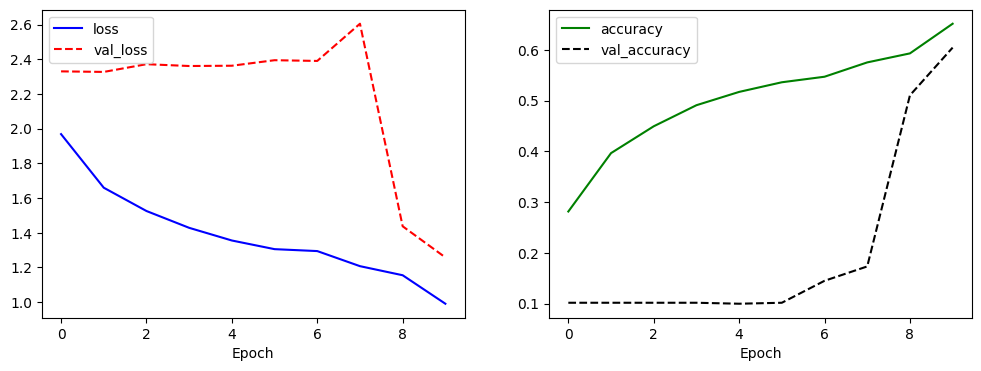

In [5]:
import matplotlib.pyplot as plt

# 성능 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], 'b-', label='loss')
plt.plot(history.history['val_loss'], 'r--', label='val_loss')
plt.xlabel('Epoch')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], 'g-', label='accuracy')
plt.plot(history.history['val_accuracy'], 'k--', label='val_accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()